In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from Tracer.fluctuator import gust_Langevin, gust_simple
from Tracer import WindField

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=10.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=10.0, z0=0.03, z_ref=10.0


In [2]:
file = '../RANS/nc files/LES-90m-8ms.nc' # z0=0.03, U_ref=8, z_ref=90
ds = xr.open_dataset(file)

In [4]:
ds.isel(x=0, y=0, t=0).u.values, ds.isel(x=0, y=0).z.values

(array([4.0191746, 6.8644958, 7.511219 , 7.5139174, 8.067065 , 7.657141 ],
       dtype=float32),
 array([ 2.5, 12.5, 22.5, 32.5, 42.5, 52.5]))

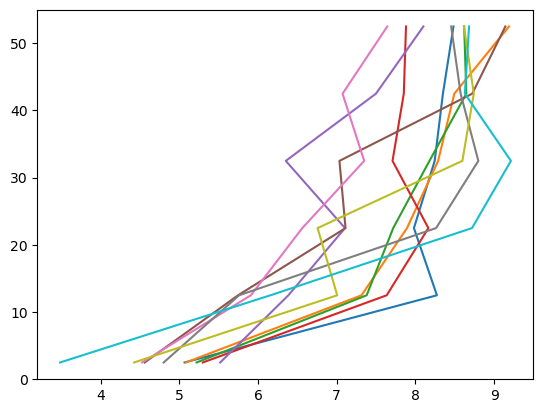

In [11]:
for i in range(0,100,10):
    plt.plot(ds.isel(x=10, y=10, t=i).u.values, ds.isel(x=0, y=0).z.values)
plt.show()

In [3]:
point_i = {'x': 0, 'y': 0, 'z': 2}  # corresponding indices in LES dataset (assuming z[4] ~ 22.5m)
data = ds.isel(**point_i)
t, z_i = data.t.values, data.z.values

In [4]:
u_ref = 8
sim_field = WindField(profile="log", direction=0, U_ref=u_ref, z_ref=90, z0=0.03)
rans_wind = WindField(profile='rans', ds = '../RANS/nc files/flowdata_2m_cartesian.nc', U_ref=8)
wind, tke, epsilon = sim_field.get_profile_at(z=z_i) # only need z for pure log
wind_rans, tke_rans, epsilon_rans = rans_wind.get_profile_at(x=0, y=0, z=z_i) # get RANS wind at specific location

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=8, z0=0.03, z_ref=90


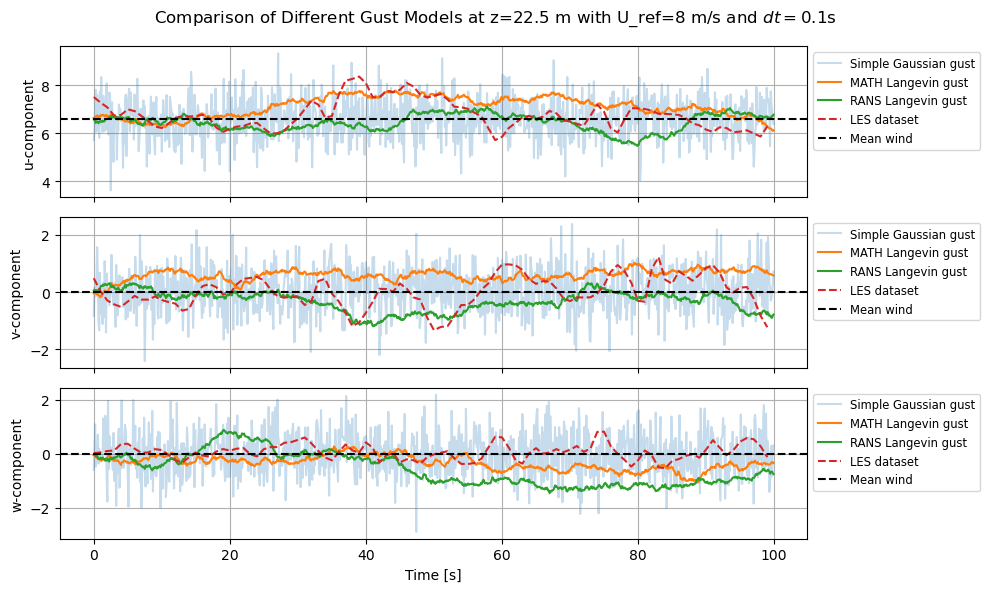

In [5]:
rng = np.random.default_rng(40)

mt = 100  # max time for simulation (s)
dt = 0.1
n_steps = int(mt/dt)
time = np.arange(0, mt, dt)

# storage arrays
simple_hist = np.zeros((n_steps, 3))
lang_hist = np.zeros((n_steps, 3))
rans_lang_hist = np.zeros((n_steps, 3))

simple_state = np.zeros(3)
gust_state_lang = np.zeros(3)
gust_state_rans_lang = np.zeros(3)


for i in range(n_steps):
    simple_hist[i] = gust_simple(wind, tke, rng)
    lang_wind, gust_state_lang = gust_Langevin(wind, tke, epsilon, gust_state_lang, rng, dt, C0=2.1, cf=1)
    lang_hist[i] = lang_wind

    rans_lang_wind, gust_state_rans_lang = gust_Langevin(wind_rans, tke_rans, epsilon_rans, gust_state_rans_lang, rng, dt, C0=2.1, cf=1)
    rans_lang_hist[i] = rans_lang_wind


# Plotting
fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

labels = ['u-component', 'v-component', 'w-component']

for j in range(3):
    axs[j].plot(time, simple_hist[:, j], label='Simple Gaussian gust', alpha=0.25)
    axs[j].plot(time, lang_hist[:, j], label='MATH Langevin gust')
    axs[j].plot(time, rans_lang_hist[:, j], label='RANS Langevin gust')
    axs[j].plot(ds.t[:mt], ds.isel(**point_i)[labels[j][0]].values[:mt], label='LES dataset', linestyle='--')
    axs[j].axhline(wind[j], linestyle='--', color='black', label='Mean wind')
    axs[j].set_ylabel(labels[j])
    axs[j].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')
    #axs[j].legend(loc='upper left', fontsize='small')
    axs[j].grid(True)

axs[2].set_xlabel('Time [s]')
plt.suptitle(f'Comparison of Different Gust Models at z={z_i:.1f} m with U_ref={u_ref} m/s and $dt={dt}$s')
plt.tight_layout()
plt.show()


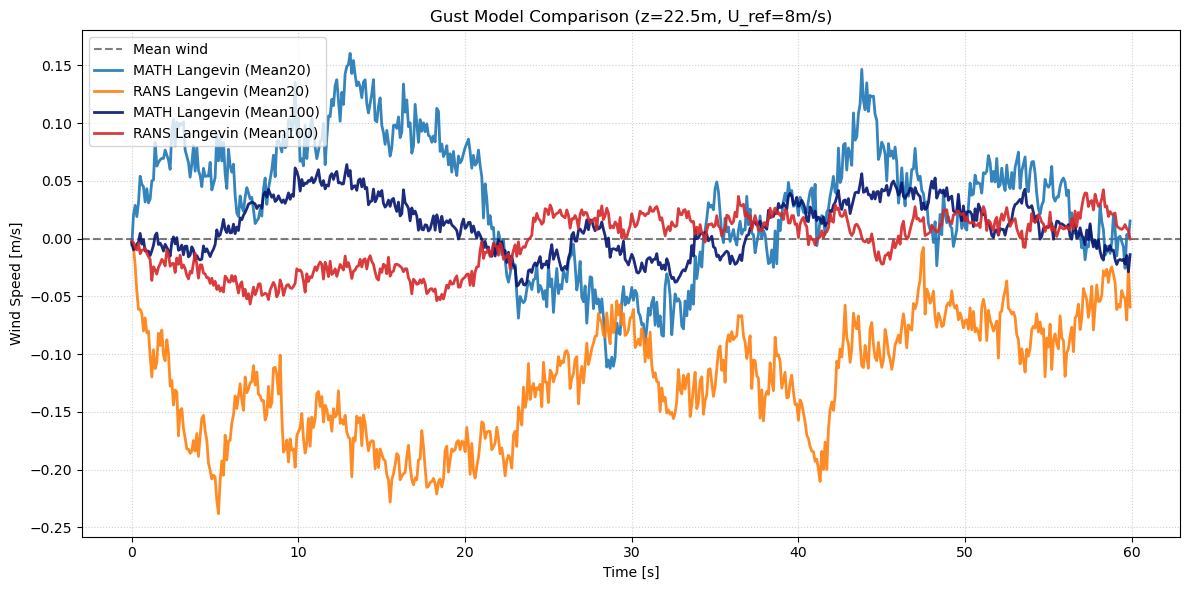

In [17]:
rng = np.random.default_rng(42)
mt = 60
dt = 0.1
n_steps = int(mt/dt)
time = np.arange(0, mt, dt)
shots_per_model = 100

# Pre-allocate 2D arrays: (row=shot, col=time_step)
simple_shots = np.zeros((shots_per_model, n_steps))
lang_shots = np.zeros((shots_per_model, n_steps))
rans_shots = np.zeros((shots_per_model, n_steps))

for s in range(shots_per_model):
    # Reset states for each independent shot
    gust_state_lang = np.array([0.0])  # Start at zero gust
    gust_state_rans_lang = np.array([0.0])  # Start at zero gust
    
    for i in range(n_steps):
        # 1. Simple Gaussian (The "Worse" model for min/max)
        simple_shots[s, i] = gust_simple(wind, tke, rng)[1]
        
        # 2. MATH Langevin
        lw, gust_state_lang = gust_Langevin(wind, tke, epsilon, gust_state_lang[0], rng, dt, C0=2.1, cf=1)
        lang_shots[s, i] = lw[1]
        
        # 3. RANS Langevin
        rw, gust_state_rans_lang = gust_Langevin(wind_rans, tke_rans, epsilon_rans, gust_state_rans_lang[0], rng, dt, C0=2.1, cf=1)
        rans_shots[s, i] = rw[1]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(12, 6))

# 1. Plot the Min/Max Envelope of the Simple Model
simple_min = np.min(simple_shots, axis=0)
simple_max = np.max(simple_shots, axis=0)
#ax.fill_between(time, simple_min, simple_max, color='gray', alpha=0.2, label='Simple Gaussian (Min/Max Range)')
ax.axhline(wind[1], linestyle='--', color='black', alpha=0.5, label='Mean wind')
#ax.plot(ds.t[:mt+1], ds.isel(**point_i)[labels[1][0]].values[:mt+1], label='LES dataset', linestyle='--', color='tab:green')

# 2. Plot the individual shots for the advanced models
colors = ['#1f77b4', '#ff7f0e', "#04146f", '#d62728'] # Blue and Orange
# for s in range(shots_per_model):
#     # Only add label to the first line to avoid legend duplication
#     l_label = 'MATH Langevin' if s == 0 else None
#     r_label = 'RANS Langevin' if s == 0 else None
    
#     ax.plot(time, lang_shots[s], color=colors[0], alpha=0.6, linewidth=1, label=l_label)
#     ax.plot(time, rans_shots[s], color=colors[1], alpha=0.6, linewidth=1, label=r_label)

ax.plot(time, np.array(lang_shots[:20]).mean(axis=0), color=colors[0], alpha=0.9, linewidth=2, label='MATH Langevin (Mean20)')
ax.plot(time, np.array(rans_shots[:20]).mean(axis=0), color=colors[1], alpha=0.9, linewidth=2, label='RANS Langevin (Mean20)')

ax.plot(time, np.array(lang_shots).mean(axis=0), color=colors[2], alpha=0.9, linewidth=2, label='MATH Langevin (Mean100)')
ax.plot(time, np.array(rans_shots).mean(axis=0), color=colors[3], alpha=0.9, linewidth=2, label='RANS Langevin (Mean100)')
# 3. Formatting
ax.set_xlabel('Time [s]')
ax.set_ylabel('Wind Speed [m/s]')
ax.set_title(f'Gust Model Comparison (z={z_i:.1f}m, U_ref={u_ref}m/s)')
ax.legend(loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()